#Entrega 1
##Autores: Florencia Gay Merino, Maximiliano Rodriguez Camps.

In [ ]:
#@title Descarga automatica
""" Para este paso utilizamos el colab de Grecco para hacer descargas automaticas https://colab.research.google.com/drive/1aoe0vPbyKS1kqsTzJ9UCytTX0wl-2e3P"""

from urllib.request import urlretrieve
import pandas as pd

url = "https://cdn.buenosaires.gob.ar/datosabiertos/datasets/ente-de-turismo/oferta-establecimientos-gastronomicos/oferta_gastronomica.csv"


urlretrieve(url, "oferta_gastronomica.csv")


('oferta_gastronomica.csv', <http.client.HTTPMessage at 0x784e7f29d510>)

In [ ]:
#@title Creación del DataFrame

df = pd.read_csv("oferta_gastronomica.csv", encoding="latin1", sep=";")
#probamos abrir el archivo con latin1 y funciono asi que creemos que usa esa codificacion
#Por otro lado, abrimos el archivo en excel primero para tener un pantallazo del csv y notamos que estaba separado por ";"

print(df.head(3)) #solo para ver si anda

           long           lat    id           nombre    categoria  \
0  -58,36330675  -34,62296347  1602     GUANTANAMERA  RESTAURANTE   
1  -58,39232963  -34,62155353   676  1843 VINACOTECA      VINERIA   
2  -58,45354227  -34,56031135   487     2080 EXPRESS  RESTAURANTE   

        cocina     ambientacion   telefono mail                    horario  \
0       CUBANA          MODERNO  4314 0770  NaN                        NaN   
1          NaN              NaN  4779 0806  NaN  lunes a domingo de 8 a 00   
2  TRADICIONAL  CLASICO PORTEÑO  4788 4500  NaN  lunes a domingo de 8 a 00   

             calle_nombre  calle_altura calle_cruce  \
0  MOREAU DE JUSTO ALICIA          2092         NaN   
1             HUMBERTO 1º          1843         NaN   
2               JURAMENTO          2080         NaN   

                 direccion_completa         barrio  comuna  codigo_postal  \
0  MOREAU DE JUSTO, ALICIA AV. 2092  Puerto Madero       1         1107.0   
1                  HUMBERTO 1º 1843

#Curaduria


In [ ]:

##esto para ver el dataframe completo e ir viendo que cambios hacer.
pd.set_option("display.max_rows", 3000)

##por la codificacion tenemos un barrio llamado "NuÃÂ±ez" en los datos de "barrio", contextualmente sabemos que se refiere a Nuñez asi que modificamos ese dato en el archivo, aparte que los datos de "NuÃÂ±ez" se corresponden a la comuna 13, donde esta Nuñez
for index, row in df.iterrows():
  if row['barrio']=="NuÃÂ±ez":
    df.at[index, 'barrio'] = "Nuñez"

##pasa lo mismo en los datos de cocina con los valores "PORTEÃA", "ESPAÃOLA", "CLASICO PORTEÃO" y  "PANQUEQUERÃ?A", contextualmente sabemos que es porteña , española clasico porteño y panquequeria respectivamente
for index, row in df.iterrows():
  if row['cocina']=="PORTEÃA":
    df.at[index, 'cocina'] = "PORTEÑA"

for index, row in df.iterrows():
  if row['cocina']=="ESPAÃOLA":
    df.at[index, 'cocina'] = "ESPAÑOLA"

for index, row in df.iterrows():
  if row['cocina']=="CLASICO PORTEÃO":
    df.at[index, 'cocina'] = "CLASICO PORTEÑO"

for index, row in df.iterrows():
  if row['cocina']=="PANQUEQUERÃ?A":
    df.at[index, 'cocina'] = "PANQUEQUERIA"



##Exploración

In [ ]:
#@title 1.1

#1) Buscando la cantidad de establecimientos y viendo que no hay valores faltantes en la columna nombre, contamos la cantidad de filas totales del dataframe, eso nos va a dar la cantidad de establecimientos gastronomicos
filas = df.shape[0]
print("La cantidad establecimiento es ", filas)

La cantidad establecimiento es  2823


In [ ]:
#@title 1.2
#2) Para ver los barrios con mayor cantidad de establecimientos contamos la cantidad de veces que se repite el mismo valor de la columna barrio.
df["barrio"].value_counts()

#como esta en orden, los primeros 10 de la serie son los barrios con mayor cantidad de establecimientos


,count
barrio,
Palermo,467
San Nicolas,454
Recoleta,327
Balvanera,215
Monserrat,149
Caballito,125
Retiro,109
Flores,85
San Telmo,80


In [ ]:
#lo podemos hacer con :
top_barrios= df['barrio'].value_counts().head(10).index

print("los barrios con mas establecimientos son", top_barrios)

los barrios con mas establecimientos son Index(['Palermo', 'San Nicolas', 'Recoleta', 'Balvanera', 'Monserrat',
       'Caballito', 'Retiro', 'Flores', 'San Telmo', 'Belgrano'],
      dtype='object', name='barrio')


In [ ]:
#@title 3)
#Usamos la misma logica que en el 2, contamos la cantidad de veces que se repite cada valor de categoria
df["categoria"].value_counts()

,count
categoria,
RESTAURANTE,1990
CAFE,334
BAR,247
CONFITERIA,55
PUB,53
VINERIA,22
SANDWICHERIA,4
DELIVERY & TAKE AWAY,2


In [ ]:
#@title 4)
# Misma logica que los ultimos dos pero con los datos de cocina, tambien estan en orden asi que los primeros son los tipos de menus mas populares
df["cocina"].value_counts()


,count
cocina,
MINUTAS,737
INTERNACIONAL,448
TRADICIONAL,297
PIZZERIA,176
PARRILLA,159
SANDWICHERIA,127
FAST FOOD,81
ITALIANA,77
MEDITERRANEA,48


In [ ]:
top_barrios2= df['cocina'].value_counts().head(10).index
print("La oferta gastronomica mas popular es", top_barrios2)

La oferta gastronomica mas popular es Index(['MINUTAS', 'INTERNACIONAL', 'TRADICIONAL', 'PIZZERIA', 'PARRILLA',
       'SANDWICHERIA', 'FAST FOOD', 'ITALIANA', 'MEDITERRANEA', 'PORTEÑA'],
      dtype='object', name='cocina')


#Visualización

In [ ]:
import seaborn as sns #lo voy a usar para hacer historamas
import matplotlib.pyplot as plt # para agregar al grafico titulos etc
import pandas as pd

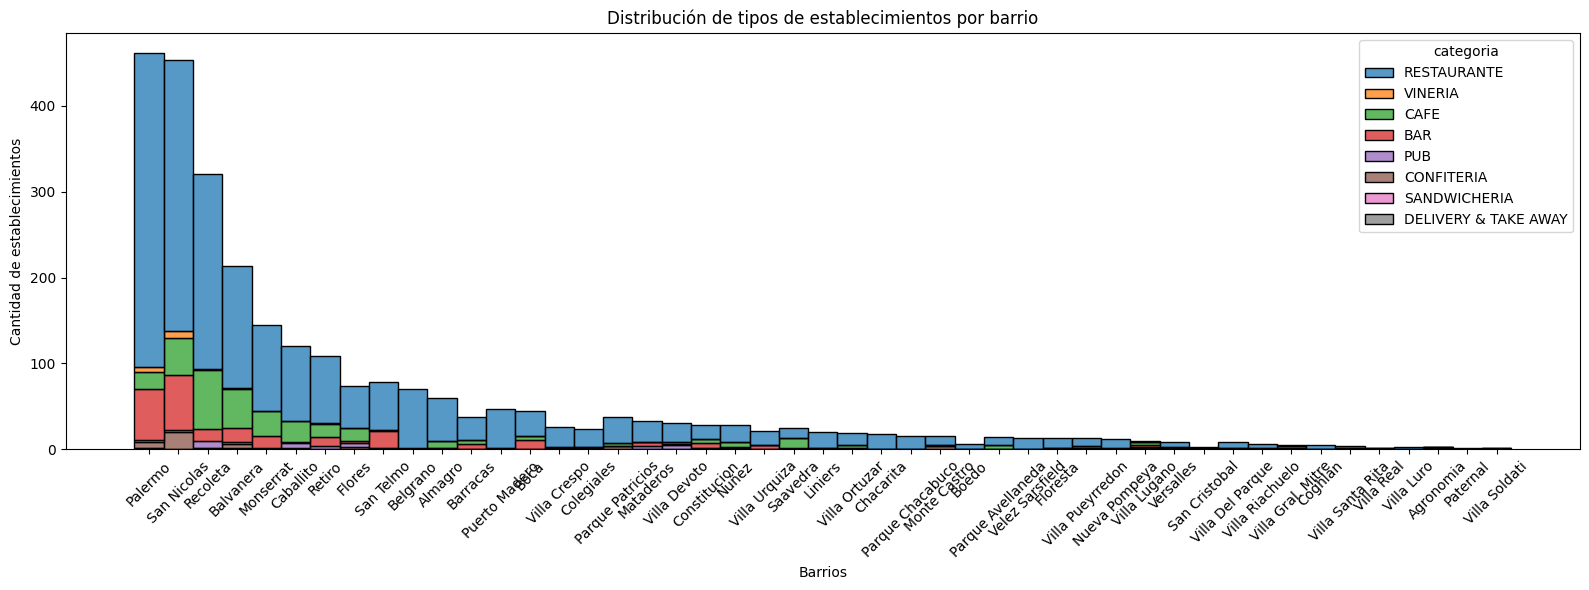

In [ ]:
orden = df['barrio'].value_counts().index # con esto voy a hacer que me queden ordenadas de la que mas establecimientos tiene a la que menos
df['barrio'] = pd.Categorical(df['barrio'], categories=orden, ordered=True) #pd.Categorical hace que la columna "barrio" sea de tipo categorica y la ordena por su frecuencia

#Grafico:
plt.figure(figsize=(16, 6))  # Más ancho para que entren todos los nombres

sns.histplot(
    data=df,
    x="barrio",
    hue="categoria",   # pone colores a cada categoria
    multiple="stack",  # me los apila
    stat="count",
)
plt.title("Distribución de tipos de establecimientos por barrio")
plt.xlabel("Barrios")
plt.ylabel("Cantidad de establecimientos")
plt.xticks(rotation=45)
plt.tight_layout() #ajusta los barrios para que no se corten
plt.show()

<ipython-input-12-32451d67b4b1>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado['barrio'] = pd.Categorical(df_filtrado['barrio'], categories=orden, ordered=True)


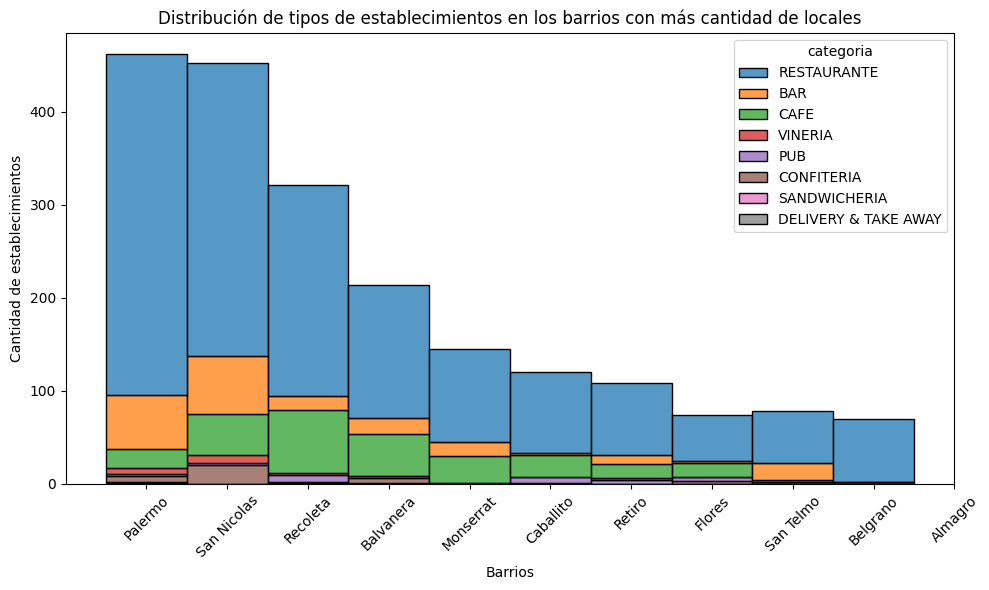

In [ ]:
#Como el grafico hace muy largo, voy a tomar solamente el top_barrios

#Filtro el dataframe para quedarme solo con esos barrios
df_filtrado = df[df['barrio'].isin(top_barrios)]

#Ordeno los barrios por cantidad total (para que el gráfico quede ordenado)
orden = df_filtrado['barrio'].value_counts().index
df_filtrado['barrio'] = pd.Categorical(df_filtrado['barrio'], categories=orden, ordered=True)

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_filtrado,
    x="barrio",
    hue="categoria",
    multiple="stack",
    stat="count",
)
plt.title("Distribución de tipos de establecimientos en los barrios con más cantidad de locales")
plt.xlabel("Barrios")
plt.ylabel("Cantidad de establecimientos")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


2.2) Utilizamos como servicios ofrecidos la columna "ambientación", ya que sobre deliverys encontramos solamente 8 columnas en horarios, luego sobre menus vegatarios y demas sentimos que eso pertenecia más a tipos de gastronomia, por lo que nos quedamos con esa clasificación.


In [ ]:
#Ahora quiero agrupar la categoria con la ambientacion y que me cuente solo las ambientaciones sin retepirlas
conteo_tipos_ambientacion = df.groupby("categoria")["ambientacion"].nunique().sort_values(ascending=False) # esta parte de sort_value lo pone en orden
print(conteo_tipos_ambientacion)




categoria
RESTAURANTE             52
BAR                     19
CAFE                    19
PUB                     11
VINERIA                  7
CONFITERIA               6
DELIVERY & TAKE AWAY     1
SANDWICHERIA             1
Name: ambientacion, dtype: int64


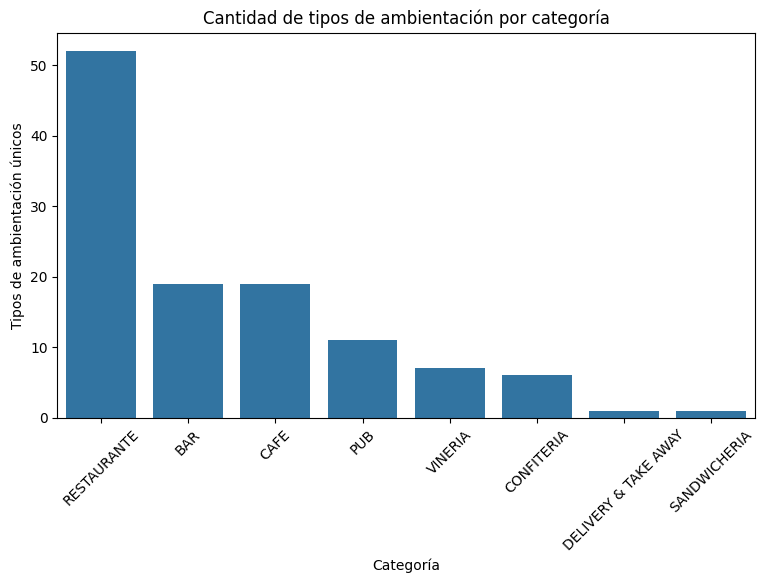

In [ ]:
#Gráfico
plt.figure(figsize=(9, 5)) #esto lo debo poner antes para que funcione.
#vuelvo a utilizar seaboarn pero esta vez con su función .barplot
sns.barplot(
    x=conteo_tipos_ambientacion.index,  # las categorías en el eje X
    y=conteo_tipos_ambientacion.values, # los valores únicos de ambientación
    order=conteo_tipos_ambientacion.index
)

plt.xticks(rotation=45) # lo pongo así, así no se chocan
plt.title("Cantidad de tipos de ambientación por categoría")
plt.xlabel("Categoría")
plt.ylabel("Tipos de ambientación únicos")

plt.show()

In [ ]:
##visualizacion extra: vimos que descargando el archivo oferta_gastronomica.shp y usando la libreria geopandas podiamos hacer un mapa real con los establecimientos.
#por las dudas
!pip install geopandas contextily gdown

# Descarga el archivo .shp desde Google Drive
import gdown
url = "https://drive.google.com/uc?id=1C_hX9U3AUs9FTZBd40XijRTsbBiLZROk&export=download"  # Cambia FILE_ID
output = "oferta-gastronomica.zip"  # Archivo comprimido de shapefiles
gdown.download(url, output, quiet=False)

# Descomprime el archivo si es un zip
import zipfile
with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall(".")


import geopandas as gpd
gdf = gpd.read_file("oferta-gastronomica.shp")


if gdf.crs is None:
    gdf.set_crs(epsg=4326, inplace=True)  # Suponemos que está en WGS84


gdf = gdf.to_crs(epsg=3857)

#crea el mapa
import matplotlib.pyplot as plt
import contextily as ctx

fig, ax = plt.subplots(figsize=(12, 10))

# dibuja puntos con colores según la columna "categoria"
gdf.plot(
    ax=ax,
    column="categoria",
    legend=True,
    categorical=True,
    cmap="Set2",
    markersize=40,
    alpha=0.8,
    edgecolor='black'
)

# Agregar mapa base
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

# Ajustes estéticos
ax.set_axis_off()
plt.title("Oferta gastronómica en CABA por categoría", fontsize=16)

# Mostrar
plt.show()
##aca se muestran los establecimientos por color, podemos ver aca donde se aglutinan mas locales, que son las zonas que uno esperaria.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 29.0 MB/s eta 0:00:00


#Análisis

In [ ]:
#1) viendo como se distribuyen lo servicios de ambientacion por barrio tomamos cuantas veces se repite cada ambientacion por barrio obteniendo:
pd.set_option("display.max_rows", 3000)
df.groupby(["barrio", "ambientacion"]).size()

In [ ]:
conteo_tipos_ambientacion = df.groupby("barrio")["ambientacion"].nunique().sort_values()
print(conteo_tipos_ambientacion)
## aca contamos la cantidad de tipos de ambientacion diferentes presentes en cada barrio, ordenados de los de menor variedad a los de mayor, y podemos ver que la variedad no esta igualmente distribuida.

In [ ]:
##2) para medir la diversidad de oferta de tipos de gastronomia, vemos primero cuantos de cada tipo de cocina hay en cada barrio contando cada vez que se repite el mismo valor de cocina para el mismo barrio
pd.set_option("display.max_rows", 1000)
df.groupby(["barrio", "cocina"]).size()

In [ ]:
#luego tomamos una aproximacion como en la pregunta anterior, vemos cuanta cantidad de tipos de cocina hay en cada barrio, los que posean una mayor cantidad de tipos de cocina diferentes van a ser los que tengan una oferta mas diversa
#podemos observar que los barrios con mayor cantidad de establecimientos tienden a tener una mayor oferta, lo cual por el caracter del analisis era de esperar ya que tienen mas posibilidades de tener mas cantidad de establecimientos diferentes entre si
conteo_tipos_ambientacion = df.groupby("barrio")["cocina"].nunique().sort_values()
print(conteo_tipos_ambientacion)